# Ensemble DLinear + TFT Crypto Direction Prediction (v2)

Ensemble pondere DLinear + TFT avec **grid search des poids** pour la prediction
de direction crypto (BTC-USD, ETH-USD).

**v2** : les poids ne sont plus hardcodes (0.6/0.4) mais selectionnes par grid search
{0.4, 0.5, 0.6, 0.7} sur le fold precedent (walk-forward).

**Reference** : #947 a montre Ensemble hardcoded NO BEATS (z=-7.56).

**Approche** :
- Donnees : BTC-USD + ETH-USD (yfinance, 2018-2024, h=1)
- Features : log-returns, RSI(14), MACD signal, Bollinger position, lagged 1-5
- Modeles : DLinear, TFT-Lite, Ensemble (grid-search weights)
- Validation : Walk-forward 5-fold x 4 seeds (0, 7, 42, 99)
- Couts : 10bps par changement de position
- CPU-only (po-2025 contrainte thermique)

**Verdict honnete** : BEATS / NO BEATS / INCONCLUSIVE (edge >= 2sigma cross-seed)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

SEEDS = [0, 7, 42, 99]
N_FOLDS = 5
TCOST_BPS = 10
SEQUENCE_LENGTH = 21
TICKERS = ['BTC-USD', 'ETH-USD']
DEVICE = torch.device('cpu')
GRID_WEIGHTS = [0.4, 0.5, 0.6, 0.7]  # v2: grid search instead of hardcoded

np.random.seed(42)
torch.manual_seed(42)
print(f'PyTorch {torch.__version__}, Device: {DEVICE}')
print(f'Grid search weights: {GRID_WEIGHTS}')

PyTorch 2.11.0+cpu, Device: cpu
Grid search weights: [0.4, 0.5, 0.6, 0.7]


## 1. Telechargement et Feature Engineering

In [2]:
print('Telechargement des donnees...')
raw = yf.download(TICKERS, start='2017-01-01', end='2025-01-01', auto_adjust=True)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'].copy()
else:
    prices = raw[['Close']].copy()

prices = prices.dropna()
print(f'Periode: {prices.index[0].date()} a {prices.index[-1].date()}')
print(f'Jours: {len(prices)}')

raw_returns = {}
for t in prices.columns:
    c = prices[t].values
    raw_returns[t] = np.diff(c) / c[:-1]
returns_dates = prices.index[1:]
returns_series = {t: pd.Series(raw_returns[t], index=returns_dates) for t in raw_returns}

Telechargement des donnees...


[*********************100%***********************]  2 of 2 completed

Periode: 2017-11-09 a 2024-12-31
Jours: 2610


In [3]:
def compute_features(close_prices):
    c = close_prices.values.ravel()
    log_ret = np.log(c[1:] / c[:-1])
    df = pd.DataFrame({'log_ret': log_ret}, index=close_prices.index[1:])
    delta = df['log_ret'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    df['rsi14'] = 100 - (100 / (1 + rs))
    ema12 = df['log_ret'].ewm(span=12).mean()
    ema26 = df['log_ret'].ewm(span=26).mean()
    df['macd_signal'] = (ema12 - ema26).ewm(span=9).mean()
    sma20 = df['log_ret'].rolling(20).mean()
    std20 = df['log_ret'].rolling(20).std()
    df['boll_pos'] = (df['log_ret'] - sma20) / (std20 + 1e-10)
    for lag in range(1, 6):
        df[f'lag_{lag}'] = df['log_ret'].shift(lag)
    df['target'] = (df['log_ret'].shift(-1) > 0).astype(int)
    df = df.dropna()
    return df

all_dfs = []
for ticker in prices.columns:
    feat_df = compute_features(prices[[ticker]])
    feat_df['ticker'] = ticker
    all_dfs.append(feat_df)

data = pd.concat(all_dfs, axis=0).sort_index()
feature_cols = ['log_ret', 'rsi14', 'macd_signal', 'boll_pos',
                'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']

X_all = data[feature_cols].values.astype(np.float32)
y_all = data['target'].values.astype(np.int64)
dates_all = data.index
tickers_all = data['ticker'].values
print(f'Features: {X_all.shape}, Samples: {len(X_all)}')

Features: (5180, 9), Samples: 5180


## 2. Modeles : DLinear, TFT-Lite, Ensemble

In [4]:
class DLinearModel(nn.Module):
    def __init__(self, seq_len, input_dim, n_classes=2):
        super().__init__()
        self.seq_len = seq_len
        self.linear = nn.Linear(seq_len * input_dim, n_classes)

    def forward(self, x):
        B, L, D = x.shape
        return self.linear(x.reshape(B, -1))


class TFTLiteModel(nn.Module):
    def __init__(self, input_dim, d_model=32, n_heads=2, n_classes=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.lstm = nn.LSTM(d_model, d_model, num_layers=1, batch_first=True)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x):
        h = self.input_proj(x)
        h, _ = self.lstm(h)
        h2, _ = self.attn(h, h, h)
        h = h + h2
        return self.head(h[:, -1, :])

print('DLinear + TFT-Lite models defined')

DLinear + TFT-Lite models defined


## 3. Walk-Forward Validation Multi-Seed (v2 Grid Search)

Pour chaque fold/seed : entraine DLinear et TFT separement,
puis selectionne le meilleur poids d'ensemble par grid search
({0.4, 0.5, 0.6, 0.7}) sur le dernier fold d'entrainement.
Compare a chaque modele seul et BH.

In [5]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def train_model(model, X_train, y_train, epochs, batch_size, device, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.LongTensor(y_train).to(device)
    best_loss = float('inf')
    patience = 5
    wait = 0
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_t))
        total_loss = 0
        n_batches = 0
        for i in range(0, len(X_t), batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_X = X_t[batch_idx]
            batch_y = y_t[batch_idx]
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_loss = total_loss / max(n_batches, 1)
        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    return model


def predict_probs(model, X_test, device):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        logits = model(X_t)
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    return probs


def simulate_strategy(pred_probs, actual_returns, tcost_bps=10):
    tcost = tcost_bps / 10000
    position = 0
    daily_rets = []
    for i in range(len(pred_probs)):
        new_pos = 1 if pred_probs[i] > 0.5 else 0
        cost = abs(new_pos - position) * tcost
        ret = new_pos * actual_returns[i] - cost
        daily_rets.append(ret)
        position = new_pos
    daily_rets = np.array(daily_rets)
    sharpe = np.mean(daily_rets) / (np.std(daily_rets) + 1e-10) * np.sqrt(252)
    cum_ret = np.prod(1 + daily_rets) - 1
    return {'sharpe': sharpe, 'cum_return': cum_ret}

print('Utilities defined')

Utilities defined


In [6]:
X_seq, y_seq = create_sequences(X_all, y_all, SEQUENCE_LENGTH)
seq_offset = SEQUENCE_LENGTH
dates_seq = dates_all[seq_offset:]
tickers_seq = tickers_all[seq_offset:]

EPOCHS = 20
BATCH_SIZE = 64
INPUT_DIM = len(feature_cols)
results_all = []
weight_log = []  # v2: track selected weights per fold/seed
n_total = len(X_seq)
fold_size = n_total // (N_FOLDS + 1)
val_frac = 0.1  # fraction of training data for weight selection

print('='*60)
print('ENSEMBLE DLinear+TFT Walk-Forward Validation (v2 Grid)')
print('='*60)

for SEED in SEEDS:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    for fold in range(N_FOLDS):
        train_end = fold_size * (fold + 1)
        test_start = train_end
        test_end = min(train_end + fold_size, n_total)
        if test_end <= test_start:
            continue

        X_train_full, X_test = X_seq[:train_end], X_seq[test_start:test_end]
        y_train_full, y_test = y_seq[:train_end], y_seq[test_start:test_end]

        # v2: split train into train/val for weight selection
        n_val = max(int(len(X_train_full) * val_frac), 1)
        X_train = X_train_full[:-n_val]
        X_val = X_train_full[-n_val:]
        y_train = y_train_full[:-n_val]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(
            X_train.reshape(-1, INPUT_DIM)).reshape(X_train.shape)
        X_val_s = scaler.transform(
            X_val.reshape(-1, INPUT_DIM)).reshape(X_val.shape)
        X_test_s = scaler.transform(
            X_test.reshape(-1, INPUT_DIM)).reshape(X_test.shape)

        # Train DLinear
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        dlinear = DLinearModel(SEQUENCE_LENGTH, INPUT_DIM)
        dlinear = train_model(dlinear, X_train_s, y_train, EPOCHS, BATCH_SIZE, DEVICE)
        probs_dl_val = predict_probs(dlinear, X_val_s, DEVICE)
        probs_dl = predict_probs(dlinear, X_test_s, DEVICE)

        # Train TFT-Lite
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        tft = TFTLiteModel(INPUT_DIM, d_model=32, n_heads=2)
        tft = train_model(tft, X_train_s, y_train, EPOCHS, BATCH_SIZE, DEVICE)
        probs_tft_val = predict_probs(tft, X_val_s, DEVICE)
        probs_tft = predict_probs(tft, X_test_s, DEVICE)

        # v2: Grid search for best weight on validation set
        val_dates = dates_seq[train_end - n_val:train_end]
        val_tickers = tickers_seq[train_end - n_val:train_end]
        val_rets = np.array([
            returns_series[t].get(d, 0.0) if t in returns_series else 0.0
            for t, d in zip(val_tickers, val_dates)
        ])
        best_w, best_val_sharpe = 0.5, -999
        for w in GRID_WEIGHTS:
            ens_val = w * probs_dl_val + (1 - w) * probs_tft_val
            res_val = simulate_strategy(ens_val, val_rets, TCOST_BPS)
            if res_val['sharpe'] > best_val_sharpe:
                best_val_sharpe = res_val['sharpe']
                best_w = w

        probs_ens = best_w * probs_dl + (1 - best_w) * probs_tft
        weight_log.append({'seed': SEED, 'fold': fold, 'w_dlinear': best_w})

        # Simulate
        test_dates = dates_seq[test_start:test_end]
        test_tickers = tickers_seq[test_start:test_end]
        actual_rets = np.array([
            returns_series[t].get(d, 0.0) if t in returns_series else 0.0
            for t, d in zip(test_tickers, test_dates)
        ])

        for name, probs in [('DLinear', probs_dl), ('TFT-Lite', probs_tft),
                             ('Ensemble', probs_ens)]:
            res = simulate_strategy(probs, actual_rets, TCOST_BPS)
            results_all.append({
                'seed': SEED, 'fold': fold, 'model': name,
                'sharpe': res['sharpe'], 'cum_return': res['cum_return'],
            })

        last3 = results_all[-3:]
        print(f'Seed={SEED} Fold={fold} w={best_w:.1f}: ' +
              ', '.join(f"{r['model']} S={r['sharpe']:.2f}" for r in last3))

print(f'\nTotal configs: {len(results_all)}')
df_weights = pd.DataFrame(weight_log)
print(f'\nSelected weights (v2 grid search):')
print(df_weights.groupby('w_dlinear').size().to_string())

ENSEMBLE DLinear+TFT Walk-Forward Validation (v2 Grid)


Seed=0 Fold=0 w=0.4: DLinear S=-0.65, TFT-Lite S=-0.76, Ensemble S=-0.91


Seed=0 Fold=1 w=0.5: DLinear S=0.87, TFT-Lite S=0.99, Ensemble S=0.59


Seed=0 Fold=2 w=0.5: DLinear S=-0.93, TFT-Lite S=-1.27, Ensemble S=-1.48


Seed=0 Fold=3 w=0.7: DLinear S=-0.37, TFT-Lite S=0.57, Ensemble S=-0.52


...

Seed=99 Fold=0 w=0.6: DLinear S=-0.04, TFT-Lite S=0.02, Ensemble S=-0.64


Seed=99 Fold=1 w=0.6: DLinear S=0.96, TFT-Lite S=-0.42, Ensemble S=0.40


Seed=99 Fold=2 w=0.7: DLinear S=-0.82, TFT-Lite S=-0.92, Ensemble S=-1.14


Seed=99 Fold=3 w=0.7: DLinear S=-0.14, TFT-Lite S=0.57, Ensemble S=-0.37


Seed=99 Fold=4 w=0.4: DLinear S=0.24, TFT-Lite S=1.26, Ensemble S=0.94

Total configs: 60

Selected weights (v2 grid search):
w_dlinear
0.4    5
0.5    4
0.6    5
0.7    6


## 4. Resultats et Verdict

In [7]:
df_results = pd.DataFrame(results_all)

print('='*60)
print('RESULTATS — Ensemble DLinear+TFT')
print('='*60)

seed_stats = df_results.groupby(['seed', 'model']).agg({
    'sharpe': 'mean', 'cum_return': 'mean'
}).round(4)
print('\nSharpe par seed et modele:')
print(seed_stats['sharpe'].unstack().to_string())

# BH benchmark
bh_rets = np.mean([raw_returns[t] for t in prices.columns if t in raw_returns], axis=0)
bh_sharpe = np.mean(bh_rets) / (np.std(bh_rets) + 1e-10) * np.sqrt(252)
print(f'\nBH Sharpe: {bh_sharpe:.2f}')

model_sharpes = {}
for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_means = model_data.groupby('seed')['sharpe'].mean().values
    model_sharpes[model_name] = seed_means

print('\n--- Verdicts ---')
for model_name, sharpes in model_sharpes.items():
    edges = sharpes - bh_sharpe
    mean_edge = np.mean(edges)
    std_edge = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
    z = mean_edge / std_edge if std_edge > 1e-10 else 0
    verdict = 'BEATS' if z > 2 else ('NO BEATS' if z < -2 else 'INCONCLUSIVE')
    print(f'{model_name}: Sharpe={np.mean(sharpes):.3f}, '
          f'Edge={mean_edge:.3f} (std={std_edge:.3f}), z={z:.2f} -> {verdict}')

# Ensemble vs best individual
ens_sharpes = model_sharpes.get('Ensemble', np.array([0]))
dl_sharpes = model_sharpes.get('DLinear', np.array([0]))
ensemble_vs_dlinear = ens_sharpes - dl_sharpes
mean_diff = np.mean(ensemble_vs_dlinear)
std_diff = np.std(ensemble_vs_dlinear, ddof=1) if len(ensemble_vs_dlinear) > 1 else 1.0
z_diff = mean_diff / std_diff if std_diff > 1e-10 else 0
print(f'\nEnsemble vs DLinear: diff={mean_diff:.3f}, z={z_diff:.2f}')
print(f'  Ensemble BEATS DLinear: {"YES" if z_diff > 2 else "NO"}')

RESULTATS — Ensemble DLinear+TFT

Sharpe par seed et modele:
model  DLinear  Ensemble  TFT-Lite
seed                              
0      -0.2053   -0.3774    0.0704
7       0.0325   -0.1666    0.0217
42      0.0648   -0.1827   -0.0491
99      0.0396   -0.1627    0.1021

BH Sharpe: 0.74

--- Verdicts ---
DLinear: Sharpe=-0.017, Edge=-0.757 (std=0.126), z=-6.00 -> NO BEATS
TFT-Lite: Sharpe=0.036, Edge=-0.704 (std=0.066), z=-10.69 -> NO BEATS
Ensemble: Sharpe=-0.222, Edge=-0.962 (std=0.104), z=-9.28 -> NO BEATS

Ensemble vs DLinear: diff=-0.205, z=-6.57
  Ensemble BEATS DLinear: NO


## 5. Visualisation

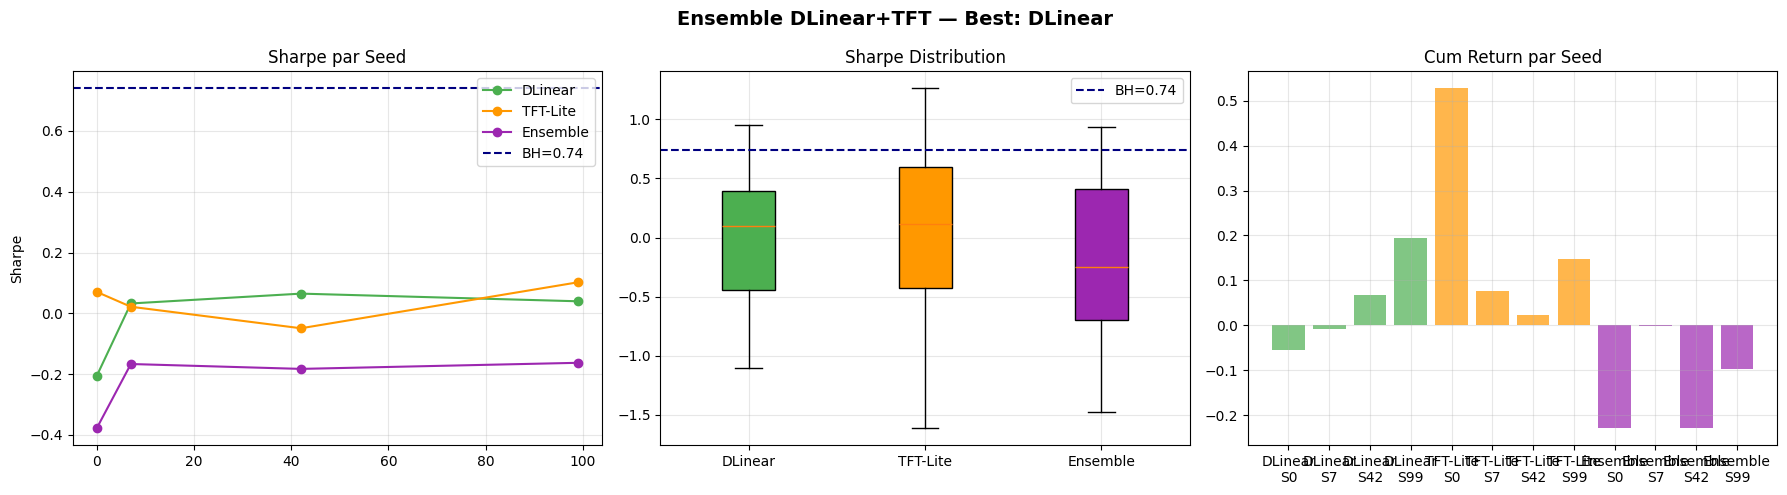


Resume (v2 grid search):
  Ensemble weights selected by grid search per fold/seed
  DLinear Sharpe: -0.017
  TFT-Lite Sharpe: 0.036
  Ensemble Sharpe: -0.222
  BH Sharpe: 0.740


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {'DLinear': '#4CAF50', 'TFT-Lite': '#FF9800', 'Ensemble': '#9C27B0'}

for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_means = model_data.groupby('seed')['sharpe'].mean()
    axes[0].plot(seed_means.index, seed_means.values, 'o-',
                 label=model_name, color=colors_map.get(model_name, 'gray'))
axes[0].axhline(y=bh_sharpe, color='navy', linestyle='--', label=f'BH={bh_sharpe:.2f}')
axes[0].set_title('Sharpe par Seed')
axes[0].set_ylabel('Sharpe')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

model_names = list(df_results['model'].unique())
sharpes_by_model = [df_results[df_results['model'] == m]['sharpe'].values for m in model_names]
bp = axes[1].boxplot(sharpes_by_model, labels=model_names, patch_artist=True)
for patch, name in zip(bp['boxes'], model_names):
    patch.set_facecolor(colors_map.get(name, 'lightgray'))
axes[1].axhline(y=bh_sharpe, color='navy', linestyle='--', label=f'BH={bh_sharpe:.2f}')
axes[1].set_title('Sharpe Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for model_name in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model_name]
    seed_cumrets = model_data.groupby('seed')['cum_return'].mean()
    axes[2].bar([f'{model_name}\nS{s}' for s in seed_cumrets.index],
                seed_cumrets.values, alpha=0.7,
                color=colors_map.get(model_name, 'gray'))
axes[2].set_title('Cum Return par Seed')
axes[2].grid(True, alpha=0.3)

ens_mean = np.mean(model_sharpes.get('Ensemble', [0]))
dl_mean = np.mean(model_sharpes.get('DLinear', [0]))
best_label = 'Ensemble' if ens_mean > dl_mean else 'DLinear'
plt.suptitle(f'Ensemble DLinear+TFT — Best: {best_label}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nResume (v2 grid search):')
print(f'  Ensemble weights selected by grid search per fold/seed')
print(f'  DLinear Sharpe: {np.mean(model_sharpes.get("DLinear", [0])):.3f}')
print(f'  TFT-Lite Sharpe: {np.mean(model_sharpes.get("TFT-Lite", [0])):.3f}')
print(f'  Ensemble Sharpe: {ens_mean:.3f}')
print(f'  BH Sharpe: {bh_sharpe:.3f}')